In [2]:
import pandas as pd

df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')
print(df_Lung_Cancer)

df_Lung_Cancer_Prediction_Dataset = pd.read_csv('Lung Cancer Prediction Dataset.csv')
print(df_Lung_Cancer_Prediction_Dataset)

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')
print(df_Lung_Cancer_Risk_Dataset)

    GENDER  AGE  SMOKING  ...  SWALLOWING DIFFICULTY  CHEST PAIN  LUNG_CANCER
0        M   69        1  ...                      2           2          YES
1        M   74        2  ...                      2           2          YES
2        F   59        1  ...                      1           2           NO
3        M   63        2  ...                      2           2           NO
4        F   63        1  ...                      1           1           NO
..     ...  ...      ...  ...                    ...         ...          ...
304      F   56        1  ...                      2           1          YES
305      M   70        2  ...                      1           2          YES
306      M   58        2  ...                      1           2          YES
307      M   67        2  ...                      1           2          YES
308      M   62        1  ...                      2           1          YES

[309 rows x 16 columns]
      AGE  GENDER  ...  STRESS_IMMUNE  

              precision    recall  f1-score   support

           0       0.45      0.62      0.53         8
           1       0.94      0.89      0.91        54

    accuracy                           0.85        62
   macro avg       0.70      0.76      0.72        62
weighted avg       0.88      0.85      0.86        62


Accuracy: 0.8548
F1-Score: 0.9143
Precision: 0.9412
Recall: 0.8889
[[ 5  3]
 [ 6 48]]


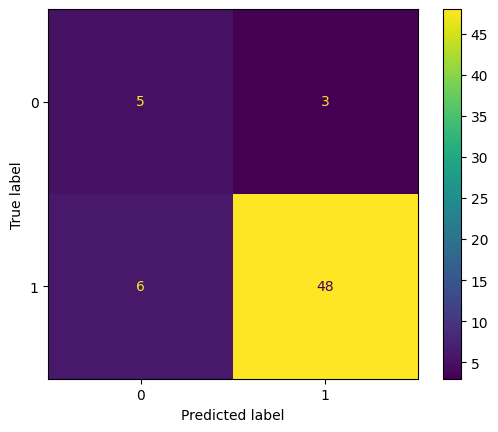


Decision Tree Results: Dataset 1 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.8902
Mean Precision: 0.9304
Mean Recall   : 0.9444
Mean F1-score : 0.9369


In [4]:
#Dataset 1 - Lung Cancer
import sklearn
from sklearn import tree #https://scikit-learn.org/stable/modules/tree.html
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder #https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/
import matplotlib.pyplot as plt


df_Lung_Cancer['GENDER'] = LabelEncoder().fit_transform(df_Lung_Cancer['GENDER'])
df_Lung_Cancer['LUNG_CANCER'] = LabelEncoder().fit_transform(df_Lung_Cancer['LUNG_CANCER'])
X1 = df_Lung_Cancer.drop(columns=['LUNG_CANCER'])
y1 = df_Lung_Cancer['LUNG_CANCER']

#BASELINE MODEL
model = tree.DecisionTreeClassifier(class_weight='balanced') #https://scikit-learn.org/stable/glossary.html#term-class_weight


X_train, X_test, y_train, y_test = train_test_split(X1,y1,test_size=0.2)

model.fit(X_train,y_train)

from sklearn.metrics import classification_report,accuracy_score, precision_score, recall_score, f1_score

print(classification_report(y_test, model.predict(X_test)))


print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

#BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nDecision Tree Results: Dataset 1 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")


              precision    recall  f1-score   support

           0       0.87      0.85      0.86       593
           1       0.79      0.81      0.80       407

    accuracy                           0.84      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.84      0.84      0.84      1000


Accuracy: 0.8380
F1-Score: 0.8034
Precision: 0.7938
Recall: 0.8133
[[507  86]
 [ 76 331]]


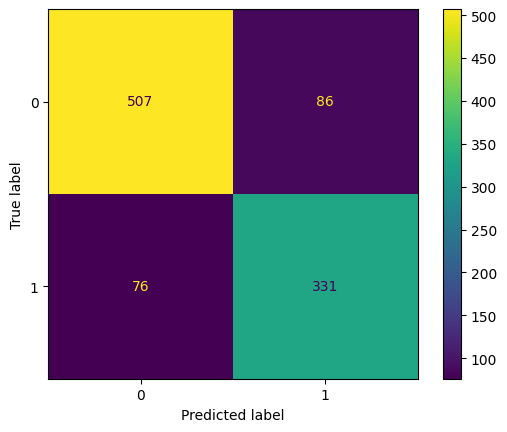

In [ ]:
#Dataset 2
df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'] = LabelEncoder().fit_transform(df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'])
X1 = df_Lung_Cancer_Prediction_Dataset.drop(columns=['PULMONARY_DISEASE'])
y1 = df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE']

model = tree.DecisionTreeClassifier(class_weight='balanced') #https://scikit-learn.org/stable/glossary.html#term-class_weight


X_train, X_test, y_train, y_test = train_test_split(X1,y1,test_size=0.2)

model.fit(X_train,y_train)

from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

              precision    recall  f1-score   support

           0       0.45      0.44      0.45      3144
           1       0.75      0.76      0.75      6856

    accuracy                           0.66     10000
   macro avg       0.60      0.60      0.60     10000
weighted avg       0.65      0.66      0.66     10000


Accuracy: 0.6569
F1-Score: 0.7515
Precision: 0.7463
Recall: 0.7569
[[1380 1764]
 [1667 5189]]


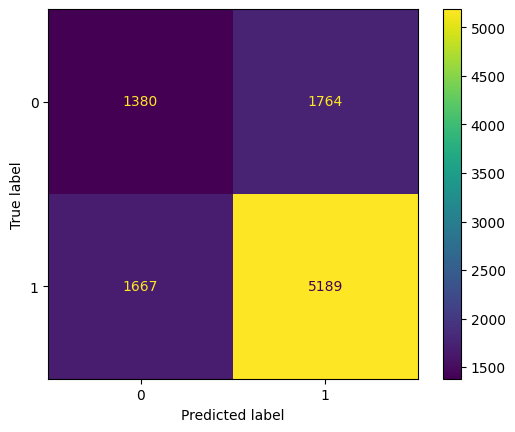

In [ ]:
#Dataset 3
for col in df_Lung_Cancer_Risk_Dataset.columns:
  df_Lung_Cancer_Risk_Dataset[col] = LabelEncoder().fit_transform(df_Lung_Cancer_Risk_Dataset[col])

x1 = df_Lung_Cancer_Risk_Dataset.drop(columns=['lung_cancer'])
y1 = df_Lung_Cancer_Risk_Dataset['lung_cancer']

model = tree.DecisionTreeClassifier(class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(x1,y1,test_size=0.2)
model.fit(X_train,y_train)

from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()